In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


In [7]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "final_federated_model.h5",
    compile=False
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 128)                 │         238,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,721 (932.50 KB)

 Trainable params: 238,721 (932.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

data = np.load("client_sequences/client_1_seq.npz")
X = data["X"]
y = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_test.shape, y_test.shape)


(59047, 5, 401) (59047,)


In [9]:
y_pred_prob = model.predict(X_test).ravel()


1846/1846 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [10]:
THRESHOLD = 0.4
y_pred = (y_pred_prob >= THRESHOLD).astype(int)


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC": auc
}

metrics


{'Accuracy': 0.2585059359493285,
 'Precision': 0.040066888160355564,
 'Recall': 0.9215587044534413,
 'F1-score': 0.07679493937796521,
 'AUC': 0.6854820309768279}

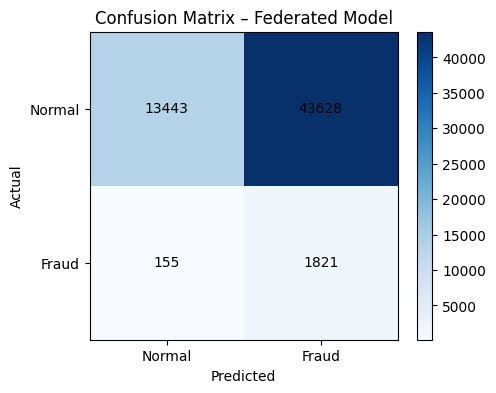

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – Federated Model")
plt.colorbar()
plt.xticks([0,1], ["Normal", "Fraud"])
plt.yticks([0,1], ["Normal", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


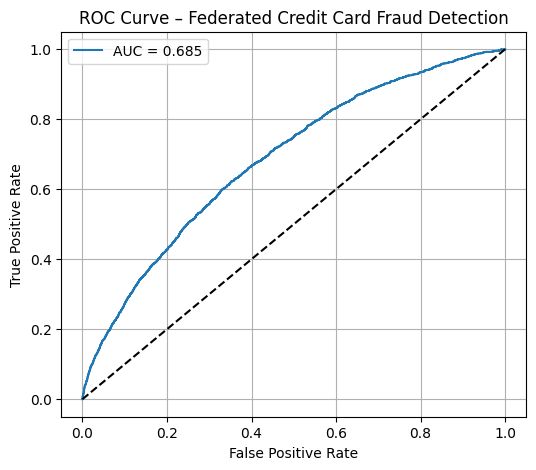

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Federated Credit Card Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()


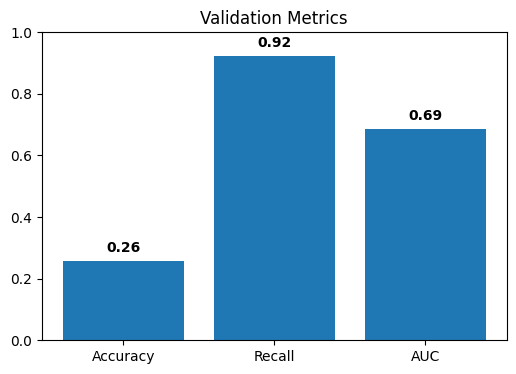

In [15]:
import matplotlib.pyplot as plt

# Use YOUR computed metrics
accuracy = accuracy        # from earlier cell
recall = recall
auc = auc

metrics_names = ["Accuracy", "Recall", "AUC"]
metrics_values = [accuracy, recall, auc]

plt.figure(figsize=(6,4))
bars = plt.bar(
    metrics_names,
    metrics_values
)

plt.ylim(0, 1)
plt.title("Validation Metrics")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()
